In [1]:
# TODO: compare means and run some statistical test.
# TODO: training time as a function of model size?

In [2]:
%load_ext autoreload
%autoreload 2
# %load_ext heat
import sys
from pathlib import Path
parent_dir = str(Path.cwd().parent)

# Prepend it to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [3]:
from importlib import reload 
import os
from validation import inference_scoring
reload(inference_scoring)
from validation.inference_scoring import model_dirs_to_edge_vectors_list, \
    model_dirs_to_timeseries_vectors, model_dirs_to_boolean_function_vectors, \
    aggregate_classification_metric, model_dirs_to_time_taken_vector, sparse_accuracy_score, \
    model_dirs_to_network_sizes
from sklearn.metrics import accuracy_score, roc_auc_score
from matplotlib import pyplot as plt
import numpy as np
import math
import seaborn as sns
import pandas as pd
import itertools
import scipy.stats
import re

In [21]:
def parse_variant(s):
    # format: "key1=val1,key2=val2,"  — values run up to the next comma
    return dict(re.findall(r'(\w+)=([^,]*)(?:,|$)', s))

In [51]:
def make_df(scoring_dict):
    df = pd.DataFrame(
        [(variant, val)
         for variant, scores in scoring_dict.items()
         for val in np.asarray(scores).ravel()],
        columns=['variant', 'score']
    )
    df['score'] = df['score'].astype(float)
    params = df['variant'].apply(parse_variant).apply(pd.Series)
    varying = params.columns[params.nunique(dropna=False) > 1]
    assert len(varying) == 1, f"expected one varying param, found {varying.tolist()}"
    df['variant'] = params[varying[0]]
    try:
        order = sorted(df['variant'].unique(), key=float)
    except ValueError:
        order = sorted(df['variant'].unique())
    df['variant'] = pd.Categorical(df['variant'], categories=order, ordered=True)
    return df, order

def box_figure(metrics, suptitle):
    n = len(metrics)
    fig, axs = plt.subplots(1, n, figsize=(5.0 * n, 3), squeeze=False)
    axs = axs[0]
    fig.suptitle(suptitle)
    for ax, (title, scoring_dict) in zip(axs, metrics.items()):
        df, order = make_df(scoring_dict)
        sns.boxplot(ax=ax, data=df, x='variant', y='score',
                    order=order, showfliers=False, color='royalblue')
        ax.set_title(title)
        ax.set_xlabel("noise %")
        ax.set_ylabel("accuracy")
    lo = min(ax.get_ylim()[0] for ax in axs)
    hi = max(ax.get_ylim()[1] for ax in axs)
    for ax in axs:
        ax.set_ylim(lo, hi)
    fig.tight_layout()
    return fig

def line_figure(metrics, suptitle):
    n = len(metrics)
    fig, axs = plt.subplots(1, n, figsize=(5.0 * n, 3), squeeze=False)
    axs = axs[0]
    fig.suptitle(suptitle)
    for ax, (title, scoring_dict) in zip(axs, metrics.items()):
        df, order = make_df(scoring_dict)
        avg = df.groupby('variant', observed=True)['score'].mean().reindex(order)
        ax.plot(range(len(order)), avg.values, marker='o', color='black')
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        ax.set_title(title)
        ax.set_xlabel("noise %")
        ax.set_ylabel("accuracy")
    lo = min(ax.get_ylim()[0] for ax in axs)
    hi = max(ax.get_ylim()[1] for ax in axs)
    for ax in axs:
        ax.set_ylim(lo, hi)
    fig.tight_layout()
    return fig

# Initial learning

In [37]:
inference_results_parent_dir = os.path.join(parent_dir, "inferred_models", "generated", "initial_learning")
inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(inference_results_parent_dir) if 
                           f.is_dir()}
model_names = [f.name for f in os.scandir(next(iter(inference_variant_paths.values())))
                   if f.is_dir()]

In [38]:
variant_timeseries_train_reference_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_reference_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in inference_variant_paths.items()}
variant_timeseries_train_real_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in inference_variant_paths.items()}
variant_timeseries_test_reference_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_reference_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in inference_variant_paths.items()}
variant_timeseries_test_real_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in inference_variant_paths.items()}

variant_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in inference_variant_paths.items()}

network_sizes_nodes = model_dirs_to_network_sizes(next(iter(inference_variant_paths.values())), with_edges=False) 
network_sizes_all = model_dirs_to_network_sizes(next(iter(inference_variant_paths.values())), with_edges=True) 

variant_edge_scores = dict()
for v, p in inference_variant_paths.items():
    variant_edge_scores[v] = [float(np.load(os.path.join(
        p, name, "edge_accuracy_score.npy"))) for name in model_names]

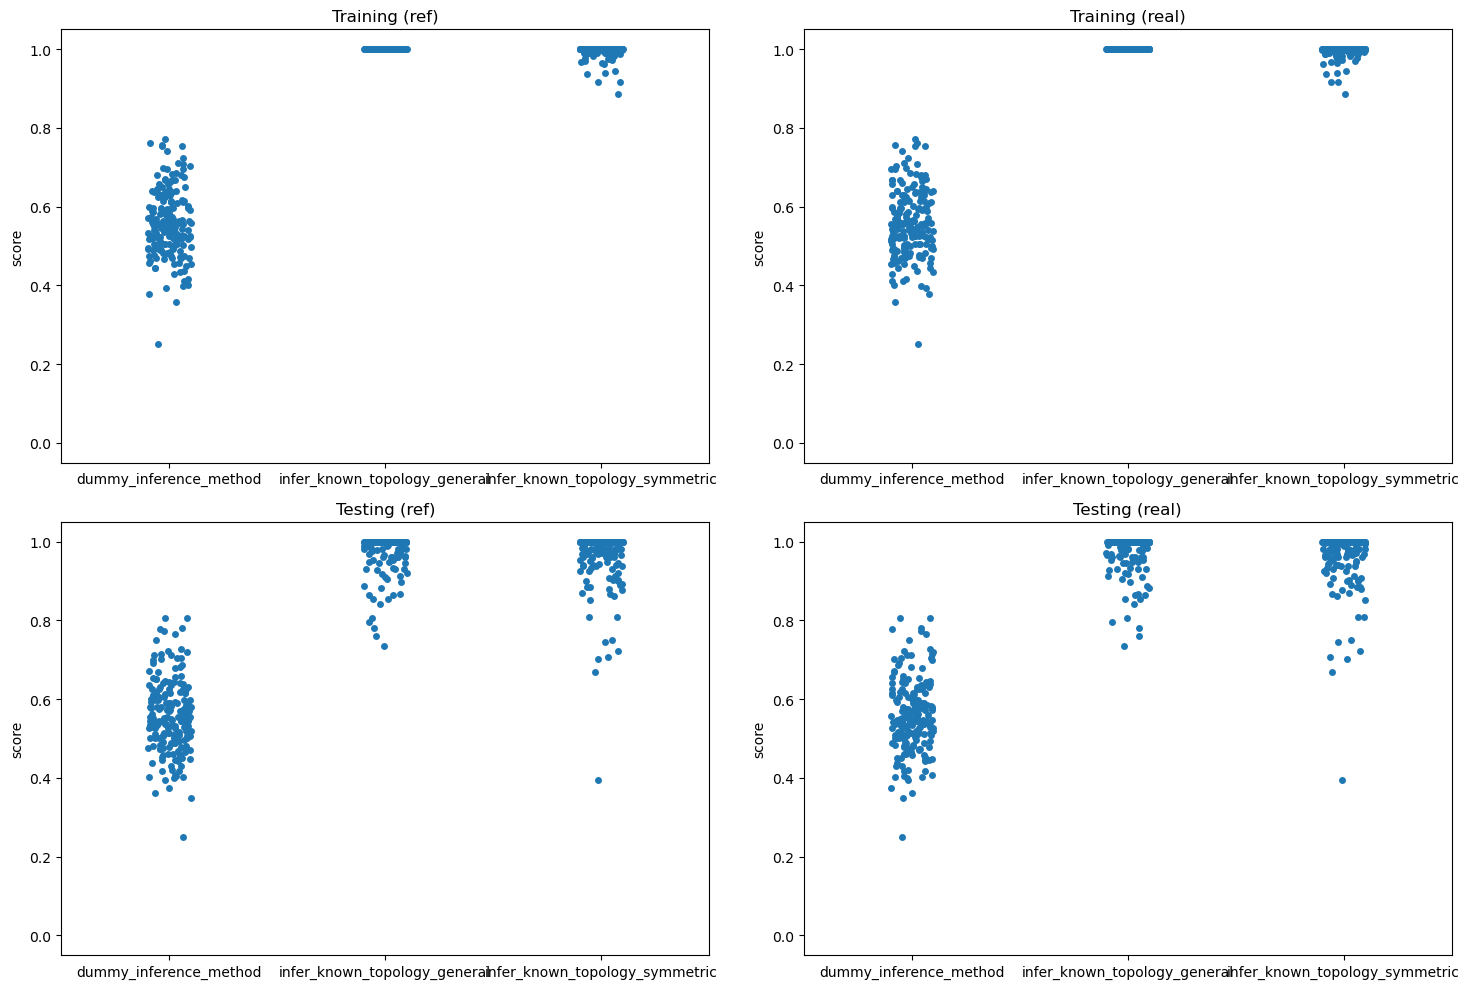

In [39]:
metrics = {'Training (ref)':  variant_timeseries_train_reference_scores,
           'Training (real)': variant_timeseries_train_real_scores,
           'Testing (ref)':   variant_timeseries_test_reference_scores,
           'Testing (real)':  variant_timeseries_test_real_scores}
fig, axs = plt.subplots(2, 2, figsize=(15.0, 10.0))
for idx, (title, scoring_dict) in enumerate(metrics.items()):
    ax = axs[idx // 2, idx % 2]
    df, order = make_df(scoring_dict)
    sns.stripplot(ax=ax, data=df, x='variant', y='score', order=order)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
fig.savefig("sanity", dpi=400)
plt.show()
print("\n\n")

In [8]:
# plt.rc('figure', figsize=(15.0, 5.0))
# fig, ax = plt.subplots(1, 1)
# variants, values = zip(*list(variant_timings.items()))
# sns.boxplot(ax=ax, data=values, color='royalblue')
# # sns.violinplot(ax=ax, inner="quartile", data=values)
# # sns.swarmplot(ax=ax, data=values, alpha=0.3, color='black')
# # sns.stripplot(ax=ax, data=values, alpha=0.3, color='black')
# ax.set_xticklabels(variants, rotation=0);
# ax.title.set_text("Training time")
# ax.set_ylim(-0.05, 4.05)
# plt.show()
# print("\n\n")

In [9]:
# ordered_model_names = list(model_names)
# plt.rc('figure', figsize=(15.0, 5.0))
# fig, axs = plt.subplots(1, 2)
# for index, variant in enumerate(variant_timings.keys()):
#     ax = axs[index]
#     timings = variant_timings[variant]
#     network_sizes = network_sizes_nodes
#     sns.scatterplot(x=network_sizes, y=timings, ax=ax)
# #     ax.set_xticklabels(network_sizes, rotation=0);
#     ax.title.set_text("Training time by model size (nodes)\n{}".format(variant))
#     ax.set_ylim(-0.05, 5.05)
# plt.show()
# print("\n\n")

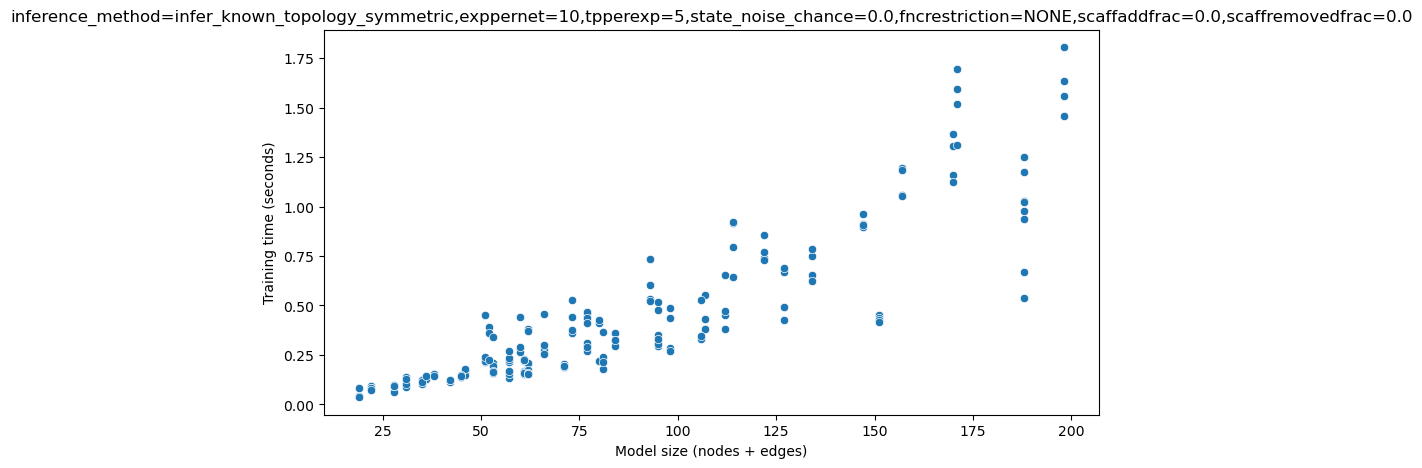

In [10]:
ordered_model_names = list(model_names)
plt.rc('figure', figsize=(10.0, 5.0))
fig, axs = plt.subplots(1, 1)
for index, variant in enumerate(variant_timings.keys()):
    ax = axs
    timings = variant_timings[variant]
    network_sizes = network_sizes_all
    sns.scatterplot(x=network_sizes, y=timings, ax=ax)
#     ax.set_xticklabels(network_sizes, rotation=0);
#     ax.title.set_text("Training time by model size (nodes + edges)\n{}".format(variant))
    ax.title.set_text(variant)
    ax.set_xlabel("Model size (nodes + edges)")
    ax.set_ylabel("Training time (seconds)")
#     ax.set_ylim(-0.05, 5.05)
#     ax.set_yscale('log')

    break # sorry future meeeeee
    
plt.savefig("training time", dpi=400)
plt.show()
print("\n\n")

# Noise Robustness

In [40]:
inference_results_parent_dir = os.path.join(parent_dir, "inferred_models", "noise_robustness")
state_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                                                        "state")) if f.is_dir()}
scaffold_add_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                                                        "scaffold_add")) if f.is_dir()}
scaffold_remove_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                                                        "scaffold_remove")) if f.is_dir()}

In [41]:
state_timeseries_test_reference_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_reference_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in state_inference_variant_paths.items()}
state_timeseries_test_real_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in state_inference_variant_paths.items()}
scaffold_add_timeseries_test_real_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_inference_variant_paths.items()}
scaffold_remove_timeseries_test_real_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_inference_variant_paths.items()}

scaffold_add_timeseries_test_reference_scores = {variant_name: [np.load(os.path.join(path, model_name,
                                                       "timeseries_reference_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_inference_variant_paths.items()}
scaffold_remove_timeseries_test_reference_scores = {variant_name: [np.load(os.path.join(path, model_name,
                                                       "timeseries_reference_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_inference_variant_paths.items()}
state_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in state_inference_variant_paths.items()}
scaffold_add_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_add_inference_variant_paths.items()}
scaffold_remove_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_remove_inference_variant_paths.items()}

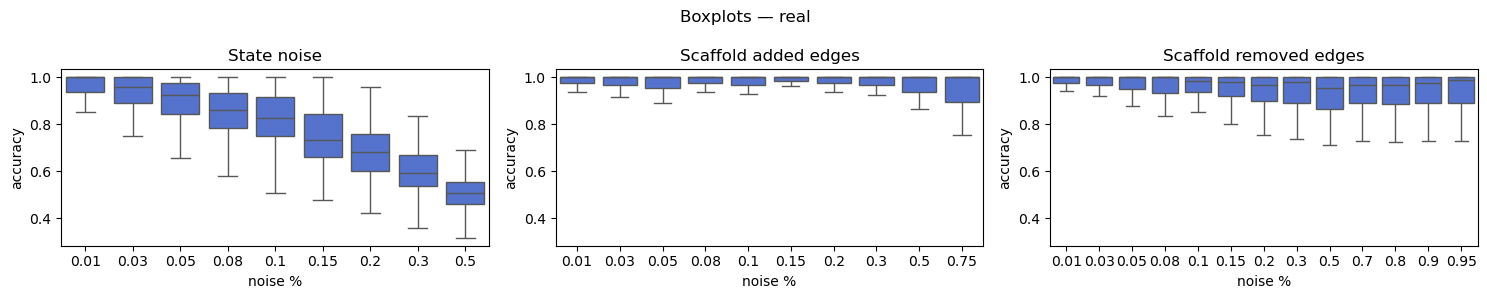

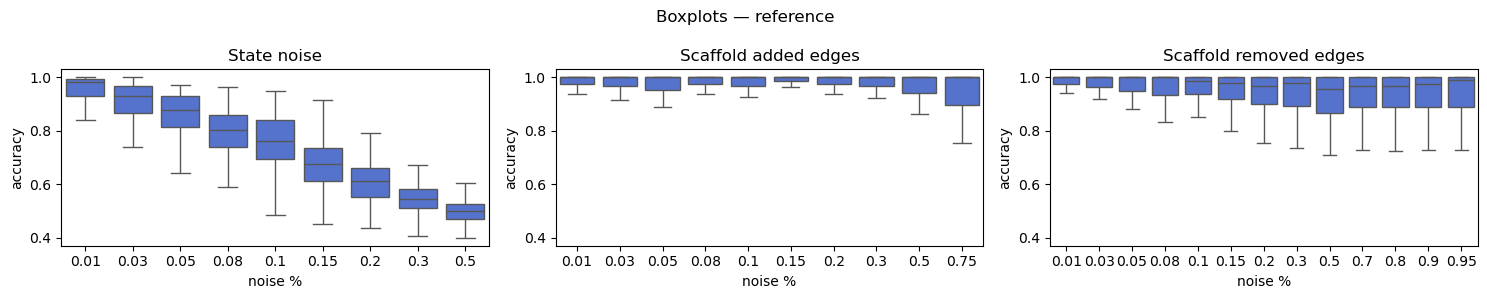

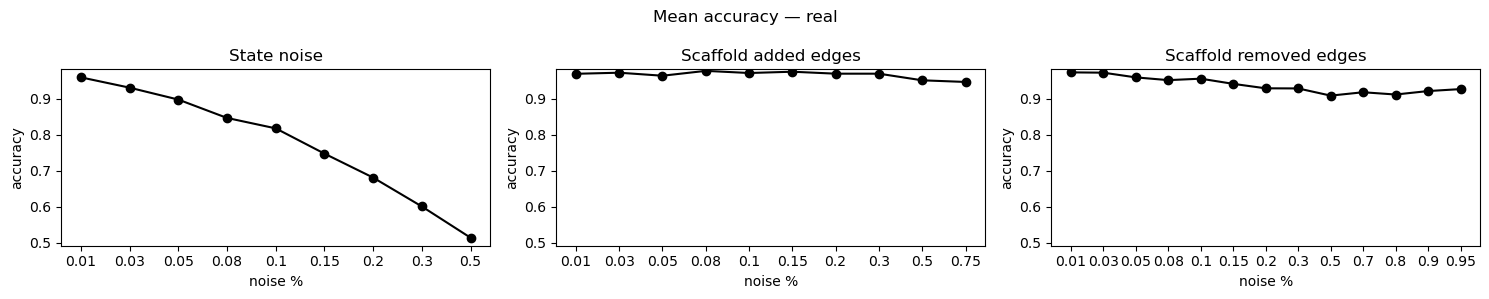

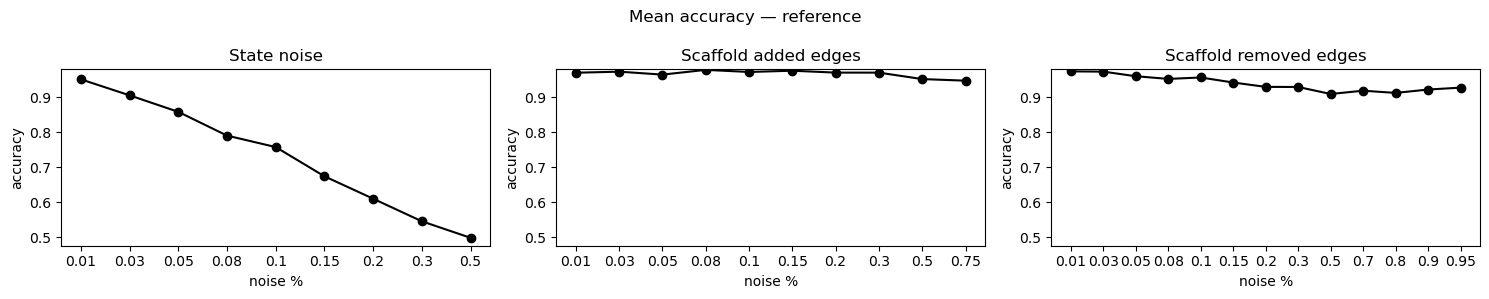

In [52]:
metrics_real = {'State noise': state_timeseries_test_real_scores,
                'Scaffold added edges': scaffold_add_timeseries_test_real_scores,
                'Scaffold removed edges': scaffold_remove_timeseries_test_real_scores}
metrics_ref = {'State noise': state_timeseries_test_reference_scores,
               'Scaffold added edges': scaffold_add_timeseries_test_reference_scores,
               'Scaffold removed edges': scaffold_remove_timeseries_test_reference_scores}


box_real_fig = box_figure(metrics_real, "Boxplots — real")
box_ref_fig = box_figure(metrics_ref, "Boxplots — reference")
line_real_fig = line_figure(metrics_real, "Mean accuracy — real")
line_ref_fig = line_figure(metrics_ref, "Mean accuracy — reference")
plt.show()
print("\n\n")

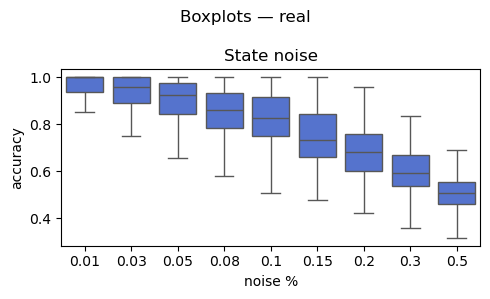

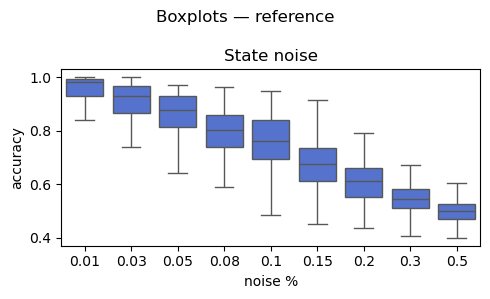

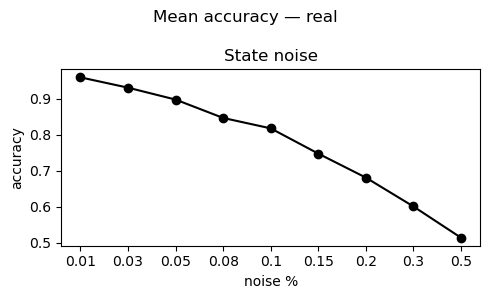

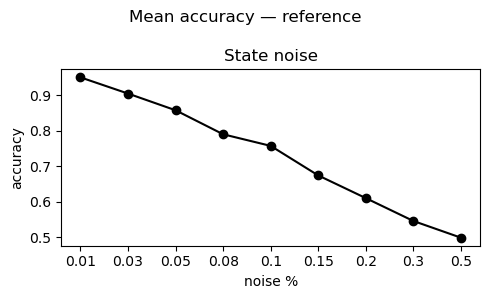

In [53]:
metrics_real = {'State noise': state_timeseries_test_real_scores}
metrics_ref = {'State noise': state_timeseries_test_reference_scores}

box_real_fig = box_figure(metrics_real, "Boxplots — real")
box_ref_fig = box_figure(metrics_ref, "Boxplots — reference")
line_real_fig = line_figure(metrics_real, "Mean accuracy — real")
line_ref_fig = line_figure(metrics_ref, "Mean accuracy — reference")
plt.show()
print("\n\n")

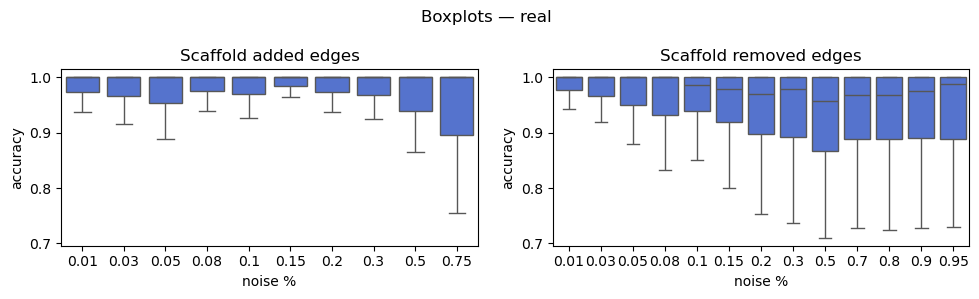

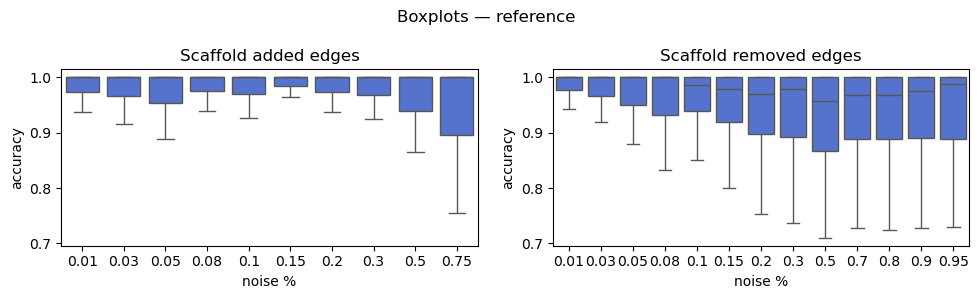

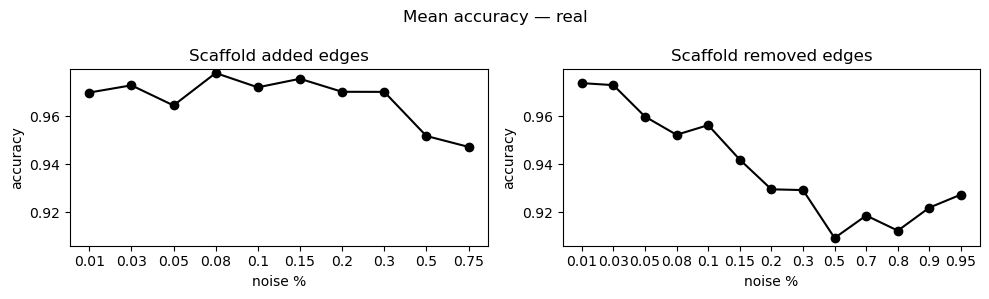

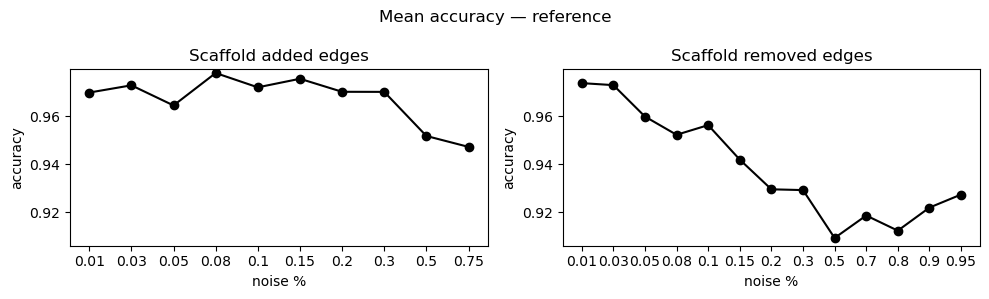

In [54]:
metrics_real = {'Scaffold added edges': scaffold_add_timeseries_test_real_scores,
                'Scaffold removed edges': scaffold_remove_timeseries_test_real_scores}
metrics_ref = {'Scaffold added edges': scaffold_add_timeseries_test_reference_scores,
               'Scaffold removed edges': scaffold_remove_timeseries_test_reference_scores}


box_real_fig = box_figure(metrics_real, "Boxplots — real")
box_ref_fig = box_figure(metrics_ref, "Boxplots — reference")
line_real_fig = line_figure(metrics_real, "Mean accuracy — real")
line_ref_fig = line_figure(metrics_ref, "Mean accuracy — reference")
plt.show()
print("\n\n")

# Data Requirements

In [56]:
inference_results_parent_dir = os.path.join("..", "inferred_models", "data_requirement")
matrices_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                                                        "variable_matrices")) if f.is_dir()}
timepoints_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                                                        "variable_timepoints")) if f.is_dir()}

FileNotFoundError: [Errno 2] No such file or directory: '../inferred_models/generated/data_requirement/variable_matrices'

In [ ]:
matrices_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in matrices_inference_variant_paths.items()}
timepoints_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in timepoints_inference_variant_paths.items()}


matrices_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in matrices_inference_variant_paths.items()}

timepoints_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in timepoints_inference_variant_paths.items()}

variant_edge_scores = dict()
for v, p in inference_variant_paths.items():
    model_names = {f.name for f in os.scandir(p) if f.is_dir()}
    variant_edge_scores[v] = [float(np.load(os.path.join(
        p, name, "edge_accuracy_score.npy"))) for name in model_names]

In [ ]:
# metrics = {'Variable matrices test accuracy scores': matrices_timeseries_test_scores,
#            'Variable timepoints test accuracy scores': timepoints_timeseries_test_scores}
# plt.rc('figure', figsize=(15.0, 5.0))
# fig, axs = plt.subplots(1, 2)
# for idx, (title, scoring_dict) in enumerate(metrics.items()):
#     ax = axs[idx]
#     variants, values = zip(*list(sorted(scoring_dict.items(), key=lambda tup: int(tup[0]))))
#     sns.boxplot(ax=ax, data=values, showfliers=False, color='royalblue')
# #     sns.violinplot(ax=ax, inner="quartile", data=values)
# #     sns.swarmplot(ax=ax, data=values, alpha=0.3, color='black')
# #     sns.stripplot(ax=ax, data=values, alpha=0.3, color='black')
#     ax.set_xticklabels(variants, rotation=0);
#     ax.title.set_text(title)
#     ax.set_ylim(-0.05, 1.05)
# plt.show()
# print("\n\n")

In [ ]:
metrics = {'Variable matrices': matrices_timeseries_test_scores,
           'Variable timepoints': timepoints_timeseries_test_scores}
plt.rc('figure', figsize=(10.0, 5))
fig, axs = plt.subplots(1, 1)
ax = axs
data_levels = sorted(set().union(*[{int(x) for x in keyset} for keyset in metrics.values()]))
score_lists = []
for variant, variant_scores in metrics.items():
    # for some reasons the scores are saved with values as zero-dimensional numpy arrays.
    level_score_pairs = itertools.chain(*[[(level, float(score)) for score in variant_scores[str(level)]] 
                        for level in data_levels if str(level) in variant_scores])
    df = pd.DataFrame(level_score_pairs)
    df.columns = ['Amount of data', 'Accuracy']
    sns.lineplot(data=df, ax=ax, x='Amount of data', y='Accuracy', err_style='band') #'band')
ax.title.set_text("Test Accuracy, different data amounts")
plt.legend(metrics.keys())
# ax.set_ylim(0.4, 1.05)
plt.savefig("data_req", dpi=400)
plt.show()
print("\n\n")

In [ ]:
metrics = {'Variable matrices': matrices_timings,
           'Variable timepoints': timepoints_timings}
plt.rc('figure', figsize=(10.0, 5.0))
fig, axs = plt.subplots(1, 1)
ax = axs

data_levels = sorted(set().union(*[{int(x) for x in keyset} for keyset in metrics.values()]))
score_lists = []
for variant, variant_scores in metrics.items():
    # for some reasons the scores are saved with values as zero-dimensional numpy arrays.
    level_score_pairs = itertools.chain(*[[(level, float(score)) for score in variant_scores[str(level)]] 
                        for level in data_levels if str(level) in variant_scores])
    df = pd.DataFrame(level_score_pairs)
    df.columns = ['data_amount', 'Training time (seconds)']
    sns.lineplot(data=df, ax=ax, x='data_amount', y='Training time (seconds)', err_style='band') #'band')
ax.title.set_text("Training time, different amounts of data")
plt.legend(metrics.keys())
plt.savefig("data_training_time", dpi=400)
plt.show()
print("\n\n")

# Model Restriction

In [ ]:
inference_results_parent_dir = os.path.join("..", "inferred_models", "generated", "model_restriction")
inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(inference_results_parent_dir) if f.is_dir()}

In [ ]:
variant_timeseries_train_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                        for variant_name, path in inference_variant_paths.items()}
variant_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                        for variant_name, path in inference_variant_paths.items()}

variant_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in inference_variant_paths.items()}

In [ ]:
metrics = {'Training scores': variant_timeseries_train_scores,
           'Testing scores': variant_timeseries_test_scores}
plt.rc('figure', figsize=(20.0, 4))
fig, axs = plt.subplots(1, 2)
for idx, (title, scoring_dict) in enumerate(metrics.items()):
    ax = axs[idx]
    variants, values = zip(*list(sorted(scoring_dict.items(), key=lambda tup: tup[0])))
    sns.boxplot(ax=ax, data=values, showfliers=False, color='royalblue')
#     sns.violinplot(ax=ax, inner="quartile", data=values)
#     sns.swarmplot(ax=ax, data=values, alpha=0.3, color='black')
#     sns.stripplot(ax=ax, data=values, alpha=0.2, color='black')
    ax.set_xticklabels(["{}\n{}".format(*v.replace("_", " ").split(" on ")) for v in variants], rotation=0, wrap=True);
    ax.title.set_text(title)
    ax.set_ylabel("Accuracy")
#     ax.set_xlabel("Data and inference method")
#     ax.set_ylim(0.5, 1.05)
plt.savefig("model_restriction", dpi=400)
plt.show()
print("\n\n")

In [ ]:
# metrics = {'Training scores': variant_timeseries_train_scores,
#            'Testing scores': variant_timeseries_test_scores}
# plt.rc('figure', figsize=(10, 5))
# fig, axs = plt.subplots(1, 1)
# for idx, (title, scoring_dict) in enumerate(metrics.items()):
#     ax = axs
#     variants, values = zip(*list(sorted(scoring_dict.items(), key=lambda tup: tup[0])))
#     means = [np.mean(val) for val in values]
#     sns.scatterplot(x=variants, y=means)
# #     sns.boxplot(ax=ax, data=values, showfliers=False, color='royalblue')
# #     sns.violinplot(ax=ax, inner="quartile", data=values)
# #     sns.swarmplot(ax=ax, data=values, alpha=0.3, color='black')
# #     sns.stripplot(ax=ax, data=values, alpha=0.2, color='black')
#     ax.set_xticklabels(["{}\n{}".format(*v.split("on")) for v in variants], rotation=0, wrap=True);
#     ax.title.set_text(title)
#     ax.set_ylabel("Accuracy")
# ax.legend(["Training", "Testing"])
# #     ax.set_ylim(0.5, 1.05)
# plt.show()
# print("\n\n")

In [ ]:
# metrics = {'Training times': variant_timings}
# plt.rc('figure', figsize=(20.0, 4))
# fig, axs = plt.subplots(1, 1)
# for idx, (title, scoring_dict) in enumerate(metrics.items()):
#     ax = axs
#     variants, values = zip(*list(sorted(scoring_dict.items(), key=lambda tup: tup[0])))
#     sns.boxplot(ax=ax, data=values, color='royalblue', showfliers=False)
# #     sns.violinplot(ax=ax, inner="quartile", data=values)
# #     sns.swarmplot(ax=ax, data=values, alpha=0.3, color='black')
# #     sns.stripplot(ax=ax, data=values, alpha=0.2, color='black')
#     ax.set_xticklabels(["{}\n{}".format(*v.split("on")) for v in variants], rotation=0, wrap=True);
#     ax.title.set_text(title)
#     ax.set_ylim(0.0, 5)
# plt.show()
# print("\n\n")

# Unknown Topology

In [ ]:
inference_results_parent_dir = os.path.join("..", "inferred_models", "unknown_topology")
scaffold_add_general_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                           "scaffold_add", "general")) if f.is_dir()}
scaffold_add_threshold_known_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                           "scaffold_add", "symmetric")) if f.is_dir()}
scaffold_add_threshold_unknown_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                           "scaffold_add", "symmetric_topology")) if f.is_dir()}

scaffold_remove_general_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                           "scaffold_remove", "general")) if f.is_dir()}
scaffold_remove_threshold_known_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                           "scaffold_remove", "symmetric")) if f.is_dir()}
scaffold_remove_threshold_unknown_inference_variant_paths = {f.name: os.path.abspath(f.path) for 
                           f in os.scandir(os.path.join(inference_results_parent_dir, 
                           "scaffold_remove", "symmetric_topology")) if f.is_dir()}


In [ ]:
scaffold_add_general_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_general_inference_variant_paths.items()}
scaffold_add_threshold_known_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_threshold_known_inference_variant_paths.items()}
scaffold_add_threshold_unknown_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_threshold_unknown_inference_variant_paths.items()}
scaffold_add_variant_test_scores = {'general': scaffold_add_general_timeseries_test_scores,
                                    'symmetric': scaffold_add_threshold_known_timeseries_test_scores,
                                    'symmetric + topology': scaffold_add_threshold_unknown_timeseries_test_scores}

scaffold_remove_general_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_general_inference_variant_paths.items()}
scaffold_remove_threshold_known_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_threshold_known_inference_variant_paths.items()}
scaffold_remove_threshold_unknown_timeseries_test_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_test.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_threshold_unknown_inference_variant_paths.items()}
scaffold_remove_variant_test_scores = {'general': scaffold_remove_general_timeseries_test_scores,
                                    'symmetric': scaffold_remove_threshold_known_timeseries_test_scores,
                                    'symmetric + topology': scaffold_remove_threshold_unknown_timeseries_test_scores}


scaffold_add_general_timeseries_train_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_general_inference_variant_paths.items()}
scaffold_add_threshold_known_timeseries_train_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_threshold_known_inference_variant_paths.items()}
scaffold_add_threshold_unknown_timeseries_train_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_add_threshold_unknown_inference_variant_paths.items()}
scaffold_add_variant_train_scores = {'general': scaffold_add_general_timeseries_train_scores,
                                    'symmetric': scaffold_add_threshold_known_timeseries_train_scores,
                                    'symmetric + topology': scaffold_add_threshold_unknown_timeseries_train_scores}

scaffold_remove_general_timeseries_train_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_general_inference_variant_paths.items()}
scaffold_remove_threshold_known_timeseries_train_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_threshold_known_inference_variant_paths.items()}
scaffold_remove_threshold_unknown_timeseries_train_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "timeseries_real_accuracy_score_train.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_threshold_unknown_inference_variant_paths.items()}
scaffold_remove_variant_train_scores = {'general': scaffold_remove_general_timeseries_train_scores,
                                    'symmetric': scaffold_remove_threshold_known_timeseries_train_scores,
                                    'symmetric + topology': scaffold_remove_threshold_unknown_timeseries_train_scores}



scaffold_add_general_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_add_general_inference_variant_paths.items()}
scaffold_add_threshold_known_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_add_threshold_known_inference_variant_paths.items()}
scaffold_add_threshold_unknown_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_add_threshold_unknown_inference_variant_paths.items()}
scaffold_add_variant_timings = {'general': scaffold_add_general_timings,
                                    'symmetric': scaffold_add_threshold_known_timings,
                                    'symmetric + topology': scaffold_add_threshold_unknown_timings}


scaffold_remove_general_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_remove_general_inference_variant_paths.items()}
scaffold_remove_threshold_known_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_remove_threshold_known_inference_variant_paths.items()}
scaffold_remove_threshold_unknown_timings = {v: model_dirs_to_time_taken_vector(p) 
                for v, p in scaffold_remove_threshold_unknown_inference_variant_paths.items()}
scaffold_remove_variant_timings = {'general': scaffold_remove_general_timings,
                                    'symmetric': scaffold_remove_threshold_known_timings,
                                    'symmetric + topology': scaffold_remove_threshold_unknown_timings}

scaffold_add_threshold_unknown_edge_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "edge_accuracy_score.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_threshold_unknown_inference_variant_paths.items()}
scaffold_remove_threshold_unknown_edge_scores = {variant_name: [np.load(os.path.join(path, model_name, 
                                                       "edge_accuracy_score.npy"))
                                  for model_name in model_names]
                           for variant_name, path in scaffold_remove_threshold_unknown_inference_variant_paths.items()}
scaffold_edge_variant_scores = {'add': scaffold_add_threshold_unknown_edge_scores,
                                             'remove': scaffold_remove_threshold_unknown_edge_scores}

In [ ]:
metrics = {'Train scores, added edges': scaffold_add_variant_train_scores,
           'Train scores, removed edges': scaffold_remove_variant_train_scores}
plt.rc('figure', figsize=(15.0, 3))
fig, axs = plt.subplots(1, 2)
for idx, (title, scoring_dict) in enumerate(metrics.items()):
    ax = axs[idx]
    noise_levels = sorted(set().union(*[{int(x) for x in keyset} for keyset in scoring_dict.values()]))
    score_lists = []
    for variant, variant_scores in scoring_dict.items():
        # for some reasons the scores are saved with values as zero-dimensional numpy arrays.
        level_score_pairs = itertools.chain(*[[(int(level), float(score)) for score in scores] 
                            for level, scores in variant_scores.items()])
        df = pd.DataFrame(level_score_pairs)
        df.columns = ['noise %', 'Accuracy']
        sns.lineplot(data=df, ax=ax, x='noise %', y='Accuracy', err_style='band') #'band')
    ax.title.set_text(title)
#     ax.set_xticks(noise_levels)
    ax.legend(scoring_dict.keys(), loc="lower left")
plt.savefig("topology_train", dpi=400)
plt.show()
print("\n\n")
print("note different scales")

In [ ]:
metrics = {'Test scores, added edges': scaffold_add_variant_test_scores,
           'Test scores, removed edges': scaffold_remove_variant_test_scores}
plt.rc('figure', figsize=(15.0, 3))
fig, axs = plt.subplots(1, 2)
for idx, (title, scoring_dict) in enumerate(metrics.items()):
    ax = axs[idx]
    noise_levels = sorted(set().union(*[{int(x) for x in keyset} for keyset in scoring_dict.values()]))
    score_lists = []
    for variant, variant_scores in scoring_dict.items():
        # for some reasons the scores are saved with values as zero-dimensional numpy arrays.
        level_score_pairs = itertools.chain(*[[(int(level), float(score)) for score in scores] 
                            for level, scores in variant_scores.items()])
        df = pd.DataFrame(level_score_pairs)
        df.columns = ['noise %', 'Accuracy']
        sns.lineplot(data=df, ax=ax, x='noise %', y='Accuracy', err_style='band') #err_style='band')
    ax.title.set_text(title)
#     ax.set_xticks(noise_levels)
    ax.legend(scoring_dict.keys(), loc="lower left")
plt.savefig("topology_test", dpi=400)
plt.show()
print("\n\n")
print("note different scales")

In [ ]:
metrics = {'Added edges': scaffold_add_variant_timings,
           'Removed edges': scaffold_remove_variant_timings}
plt.rc('figure', figsize=(15.0, 3))
fig, axs = plt.subplots(1, 2)
for idx, (title, scoring_dict) in enumerate(metrics.items()):
    ax = axs[idx]
    noise_levels = sorted(set().union(*[{int(x) for x in keyset} for keyset in scoring_dict.values()]))
    score_lists = []
    for variant, variant_scores in scoring_dict.items():
        # for some reasons the scores are saved with values as zero-dimensional numpy arrays.
        level_score_pairs = itertools.chain(*[[(int(level), float(score)) for score in scores] 
                            for level, scores in variant_scores.items()])
        df = pd.DataFrame(level_score_pairs)
        df.columns = ['noise %', 'Training time (seconds)']
        sns.lineplot(data=df, ax=ax, x='noise %', y='Training time (seconds)', err_style='band')
    ax.title.set_text(title)
#     ax.set_xticks(noise_levels)
    ax.legend(scoring_dict.keys(), loc="upper left")
plt.savefig("topology_time", dpi=400)
plt.show()
print("\n\n")
print("note different scales")

In [ ]:
# metrics = {"only": scaffold_edge_variant_scores}
# plt.rc('figure', figsize=(10.0, 5))
# fig, axs = plt.subplots(1, 1)
# for idx, (title, scoring_dict) in enumerate(metrics.items()):
#     ax = axs
#     noise_levels = sorted(set().union(*[{int(x) for x in keyset} for keyset in scoring_dict.values()]))
#     score_lists = []
#     for variant, variant_scores in scoring_dict.items():
#         print(variant_scores)
#         # for some reasons the scores are saved with values as zero-dimensional numpy arrays.
#         level_score_pairs = itertools.chain(*[[(int(level), float(score)) for score in scores] 
#                             for level, scores in variant_scores.items()])
#         df = pd.DataFrame(level_score_pairs)
#         df.columns = ['noise %', 'Accuracy']
#         sns.lineplot(data=df, ax=ax, x='noise %', y='Accuracy', err_style='band') #'band')
#     ax.title.set_text(title)
# #     ax.set_xticks(noise_levels)
#     ax.legend(scoring_dict.keys(), loc="lower left")
# plt.show()
# print("\n\n")
# print("note different scales")

## Graph properties

In [ ]:
from attractor_learning import graphs, stochastic
graphs_parent_dir = "../attractor_learning/cellcollective_models"
res_dict = dict()
for i, graph_dir in enumerate(os.scandir(graphs_parent_dir)):
    graph = graphs.Network.parse_boolean_tables(graph_dir)
    
    cur_dict = dict()
    cur_dict['mean_indegree'] = np.mean([len(v.predecessors()) for v in graph.vertices])
    cur_dict['max_indegree'] = np.max([len(v.predecessors()) for v in graph.vertices])
    cur_dict['indegree_variation_coefficient'] = scipy.stats.variation([len(v.predecessors()) for v in graph.vertices])
    cur_dict['nodes'] = len(graph)
    cur_dict['edges'] = len(graph.edges)
    attractor_dict = stochastic.estimate_attractors(graph, n_walks=5000, max_walk_len=100, 
                                                    with_basins=True) 
    cur_dict['attractors'] = len(attractor_dict)
    cur_dict['mean_attractor_length'] = np.mean([len(a) for (a, _) in attractor_dict])
    cur_dict['max_attractor_length'] = np.max([len(a) for (a, _) in attractor_dict])
    cur_dict['basin_size_variation_coefficient'] = scipy.stats.variation([b for (_, b) in attractor_dict])
    res_dict[i] = cur_dict

properties = pd.DataFrame.from_dict(res_dict).transpose()

In [ ]:
properties.hist(figsize=(20, 10))
plt.savefig("attractor_properties", dpi=400)